<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
   Energy Load Forecasting: Predicting Future Electricity Demand with LSTM,and RNN

</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px; padding: 10px;
            background:#F2FFFF;">

<h2><b>Project Description</b></h2>

<h3><b>Title:</b><br>
Energy Load Forecasting: Predicting Future Electricity Demand using LSTM, GRU, and RNN
</h3>

<hr>

<h3><b>Overview</b></h3>
Energy load forecasting is a critical component of modern power system management.  
This project addresses the challenge of accurately predicting future electricity demand by applying advanced deep learning and time series modeling techniques.

Using historical energy consumption data, we develop and compare multiple neural network architectures—Long Short-Term Memory (LSTM), Gated Recurrent Unit (GRU), and Recurrent Neural Networks (RNN).  
Accurate load forecasting enables utility companies to optimize power generation, minimize operational costs, and maintain grid stability while supporting the integration of renewable energy sources.

<hr>

<h3><b>Key Features</b></h3>
<ul>
  <li>Comprehensive exploratory data analysis with insightful visualizations</li>
  <li>Comparison of multiple deep learning models (LSTM, GRU, RNN)</li>
  <li>Time series feature engineering including lag variables and seasonal patterns</li>
  <li>Advanced visual analytics such as heatmaps, radial charts, and interactive plots</li>
  <li>Detailed evaluation of model performance and prediction accuracy</li>
</ul>

<hr>

<h3><b>Technical Stack</b></h3>
<ul>
  <li>Python, Pandas, NumPy</li>
  <li>Scikit-learn, XGBoost, LightGBM</li>
  <li>TensorFlow / Keras for deep learning models</li>
  <li>Matplotlib, Seaborn, Plotly for visualization</li>
  <li>Statsmodels for time series analysis</li>
</ul>

<hr>

<h3><b>Dataset</b></h3>
PJME Hourly Energy Consumption Dataset (Kaggle)

<hr>

<h3><b>Introduction and Business Problem</b></h3>
Accurate energy load forecasting is essential for utility companies and grid operators to ensure reliable power delivery and efficient energy management.  
Poor forecasting can lead to excessive generation costs, energy shortages, or grid instability.

Reliable demand prediction enables organizations to:
<ul>
  <li>Reduce operational costs through optimized energy generation</li>
  <li>Prevent blackouts and maintain grid reliability</li>
  <li>Facilitate the integration of renewable energy sources</li>
  <li>Improve financial planning, trading, and market participation</li>
</ul>

This project aims to develop a robust and scalable forecasting framework by leveraging historical load data and modern deep learning techniques, providing accurate and actionable insights for real-world energy management applications.

</div>


In [61]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.subplots as sp
import plotly.graph_objects as go
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout,GRU,Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [24]:
df = pd.read_csv(
    r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series-Energy Consumption\Energy & Electricity Forecasting LSTM.GRU,RNN\PJME_hourly.csv',
    parse_dates=['Datetime'],
    index_col='Datetime'
)
df.head()


,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Adding separate time and date columns  
      
</center></p></h1>

In [25]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofyear'] = df.index.dayofyear
df['month'] = df.index.month




df.head()

,PJME_MW,hour,dayofweek,dayofyear,month
Datetime,,,,,
2002-12-31 01:00:00,26498.0,1,1,365,12
2002-12-31 02:00:00,25147.0,2,1,365,12
2002-12-31 03:00:00,24574.0,3,1,365,12
2002-12-31 04:00:00,24393.0,4,1,365,12
2002-12-31 05:00:00,24860.0,5,1,365,12


In [26]:
df.rename (columns={'PJME_MW': 'EnergyLoad_MWh'}, inplace=True)

In [32]:
df = df[~df.index.duplicated(keep='first')]
df['EnergyLoad_MWh'] = df['EnergyLoad_MWh'].interpolate(method='time')
df.dropna(inplace=True)
df.isnull().sum()

EnergyLoad_MWh    0
hour              0
dayofweek         0
dayofyear         0
month             0
dtype: int64

In [29]:
# sort index (CRITICAL)
df = df.sort_index()

# set hourly frequency
df = df.asfreq('H')

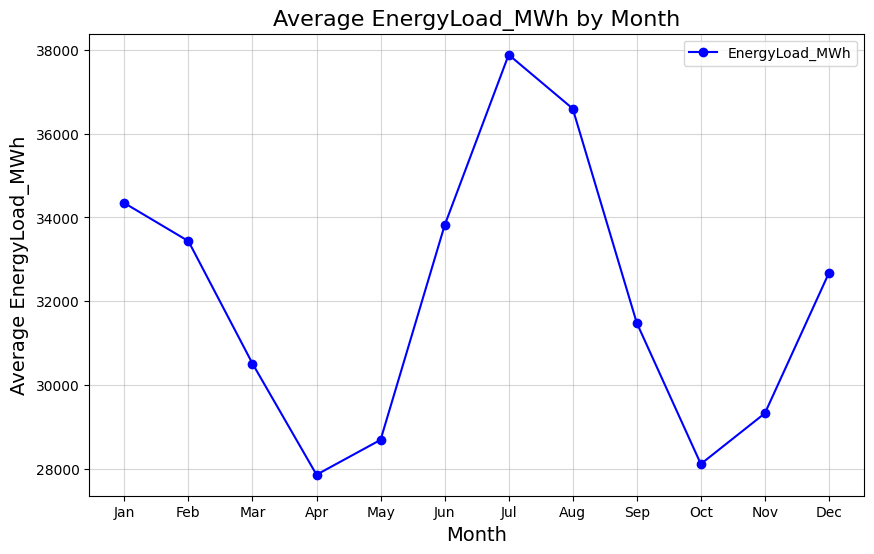

In [13]:
monthly_avg_consumption = df.groupby('month')['EnergyLoad_MWh'].mean().reset_index()

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg_consumption['month'], 
         monthly_avg_consumption['EnergyLoad_MWh'], 
         marker='o', color='b', label='EnergyLoad_MWh')
plt.title('Average EnergyLoad_MWh by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average EnergyLoad_MWh', fontsize=14)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

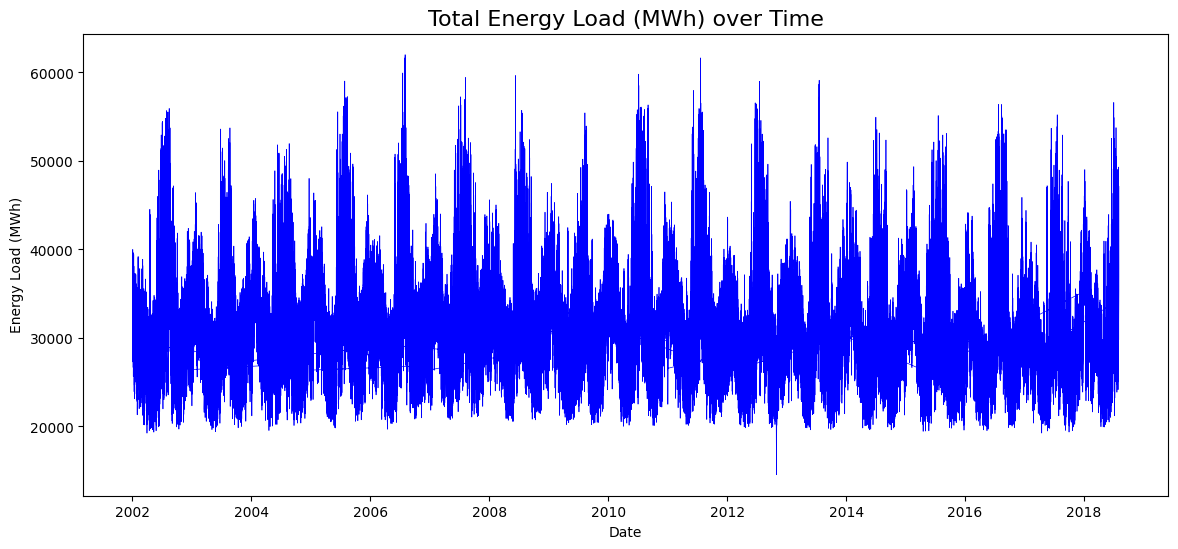

In [14]:

# Plot the entire time series
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['EnergyLoad_MWh'], linewidth=0.5, color='blue')
plt.title('Total Energy Load (MWh) over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Energy Load (MWh)')
plt.show()

# **Seasonal Decomposition**

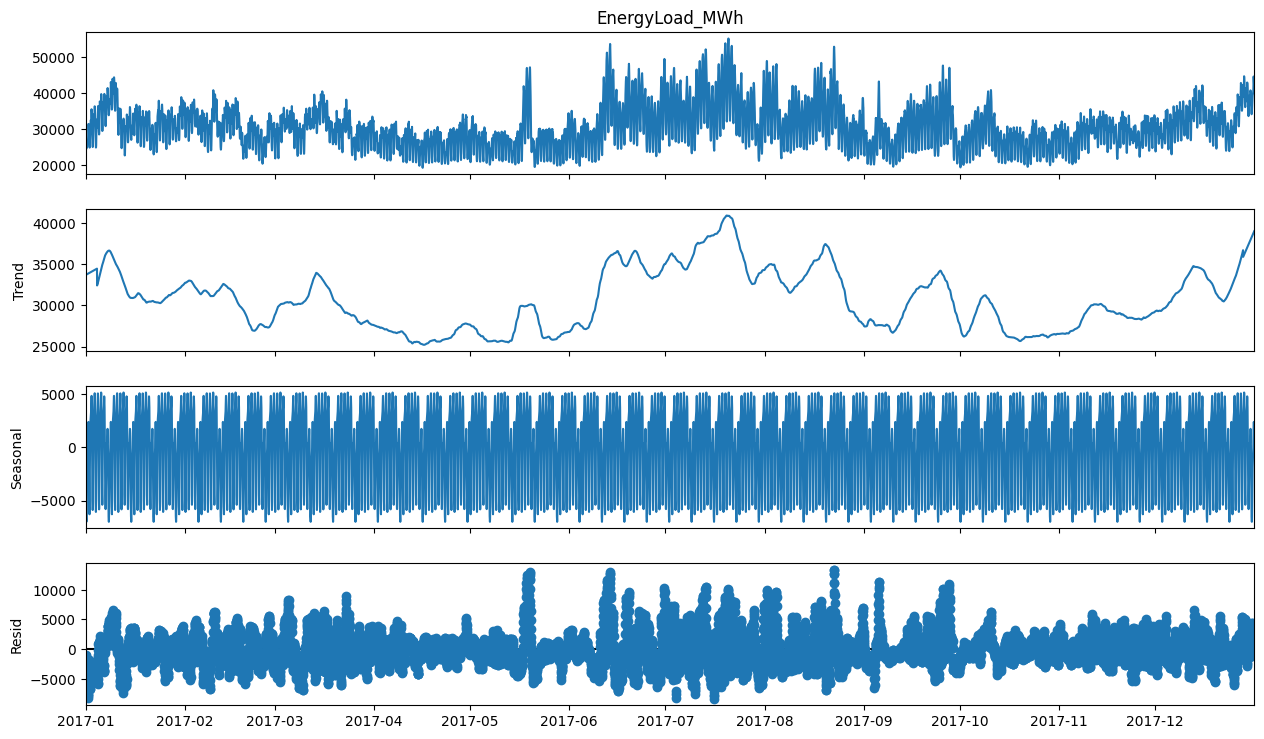

In [33]:
# Decompose the time series to see Trend, Seasonality, and Residuals
# Let's use a period of one week (24 hours * 7 days = 168 hours)
series_2017 = df.loc['2017-01-01':'2017-12-31', 'EnergyLoad_MWh']

decomposition = seasonal_decompose(
    series_2017,
    period=168,
    model='additive',
    extrapolate_trend='freq'
)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

# **Distribution of Energy Load**

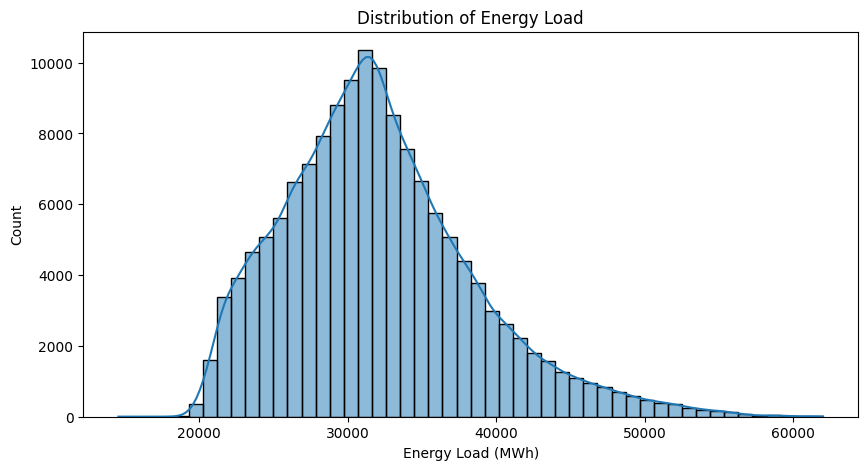

In [34]:
# Plot distribution of energy load
plt.figure(figsize=(10, 5))
sns.histplot(df['EnergyLoad_MWh'], kde=True, bins=50)
plt.title('Distribution of Energy Load')
plt.xlabel('Energy Load (MWh)')
plt.show()

# **Energy Load Distribution by Hour (Pie Chart)**

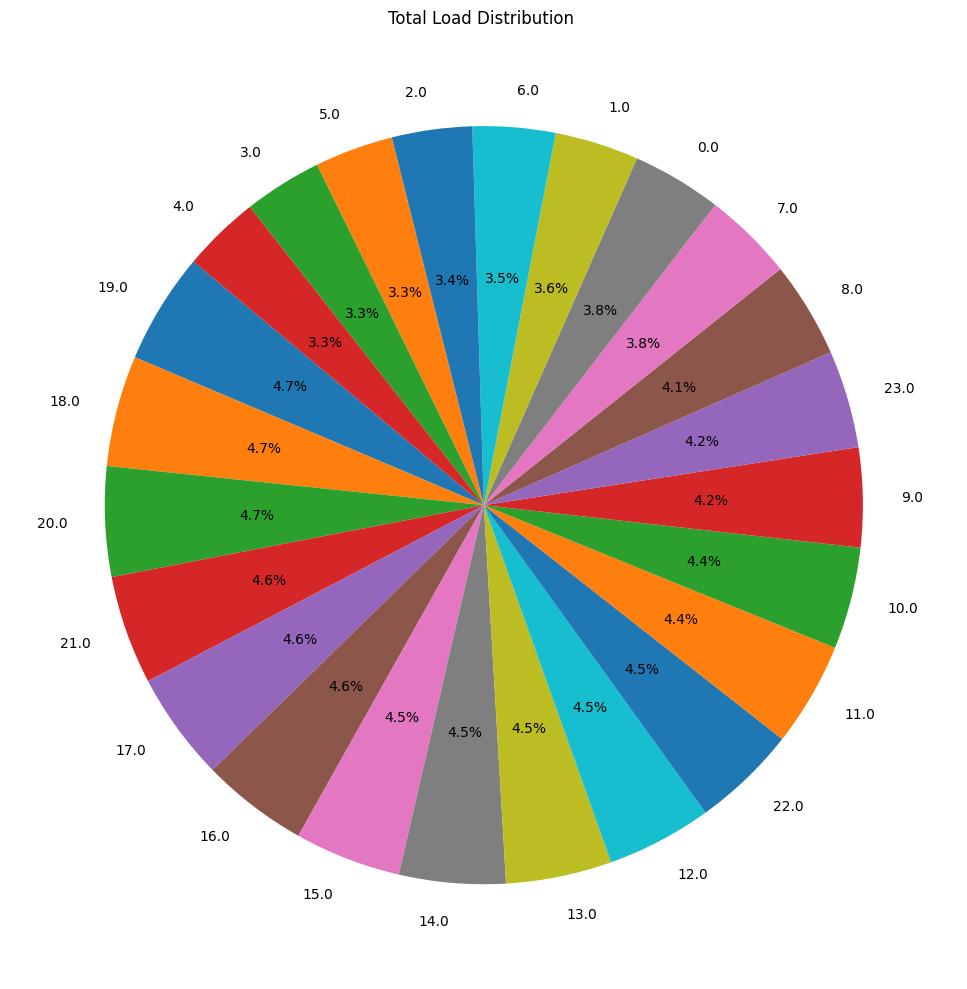

In [35]:
grouped_total_yield = df.groupby('hour')['EnergyLoad_MWh'].mean()

plt.figure(figsize=(10,10))
grouped_total_yield.sort_values(ascending=False).plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Total Load Distribution ')
plt.ylabel('')
plt.tight_layout()
plt.show()

# **Monthly Energy Consumption (Bar Plot)**

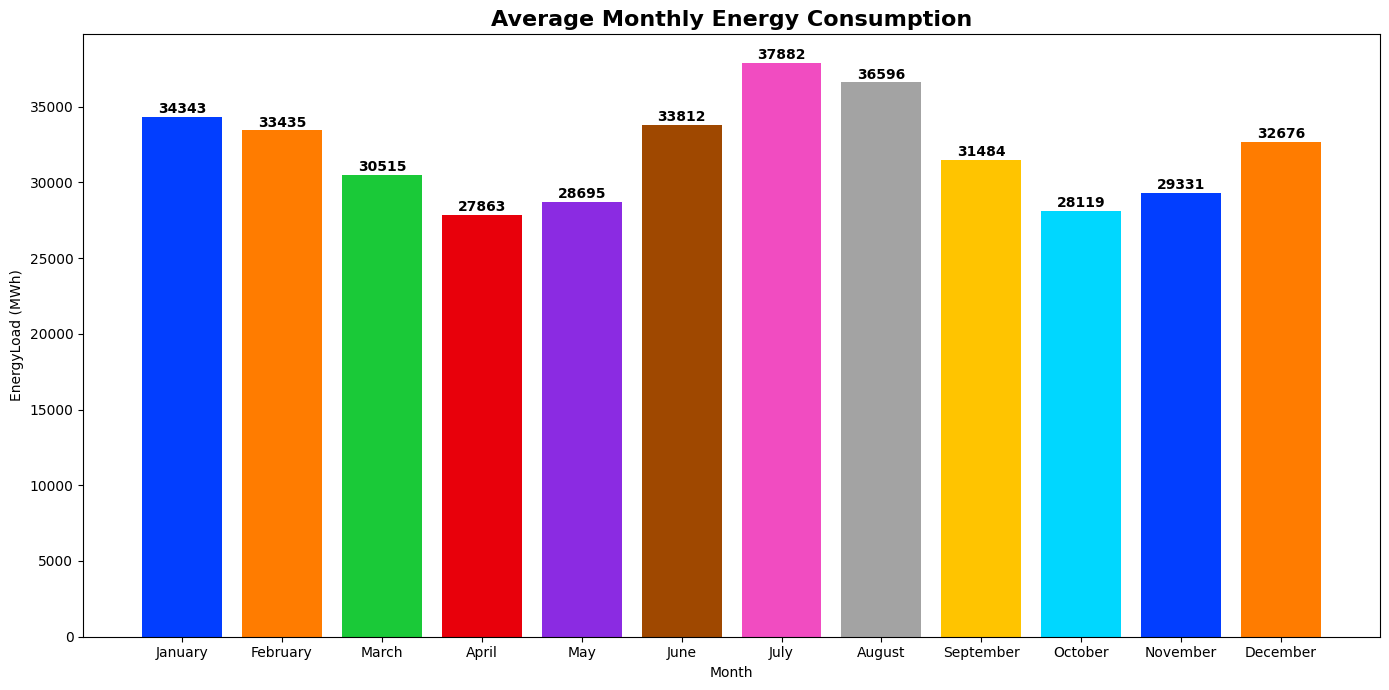

In [39]:

# Add month name for better visualization
df['month_name'] = df.index.month_name()

# Calculate average monthly consumption
monthly_avg = df.groupby('month_name')['EnergyLoad_MWh'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Define color palette
bright_palette = sns.color_palette("bright", 12)  # 12 رنگ روشن

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(monthly_avg.index, monthly_avg.values, color=bright_palette)
plt.title('Average Monthly Energy Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('EnergyLoad (MWh)')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Models</p>
</div>

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Sequence Models and RNN/LSTM</title>
</head>
<body>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px; padding: 15px; 
            background:#F2FFFF;">

<h1 style="text-align:center;">Sequence Models and Recurrent Neural Networks (RNN)</h1>

 <nav>
        <ul>
            <li><a href="#sequence-models">Sequence Models</a></li>
            <li><a href="#rnn">Recurrent Neural Network (RNN)</a></li>
            <li><a href="#implement-rnn">Implementing RNN with Keras</a></li>
            <li><a href="#lstm">Long Short Term Memory (LSTM)</a></li>
            <li><a href="#implement-lstm">Implementing LSTM with Keras</a></li>
            <li><a href="#conclusion">Conclusion</a></li>
        </ul>
    </nav>

<a id="sequence-models"></a>
    <h2>Sequence Models</h2>
    <ul>
        <li>Sequence models analyze data over time.</li>
        <li>Applications include speech recognition, NLP, time-series forecasting, and music generation.</li>
        <li>Examples: Apple's Siri, Google Voice Search.</li>
        <li>Sentiment classification examples:
            <br>“This lesson is the best in the world” vs “This lesson is nonsense.”</li>
    </ul>

<a id="rnn"></a>
    <h2>Recurrent Neural Network (RNN)</h2>
    <ul>
        <li>RNNs can remember important information from previous inputs.</li>
        <li>They are effective for sequential data (time series, speech, text, financial signals, audio, video, weather, etc.).</li>
        <li>The output is fed forward AND back into the RNN → due to internal memory.</li>
        <li>RNN has a temporal loop that allows self-feedback.</li>
        <li>RNNs have short-term memory: they remember previous time steps.</li>
        <li>This memory helps the network make better predictions based on past data.</li>
    </ul>

<h3>RNN Structures</h3>
    <ul>
        <li><strong>One-to-Many:</strong> One input → multiple outputs (e.g., Image → Caption)</li>
        <li><strong>Many-to-One:</strong> Multiple inputs → one output (e.g., sentence → sentiment)</li>
        <li><strong>Many-to-Many:</strong> Multiple inputs → multiple outputs (e.g., translation)</li>
    </ul>

<h3>RNN vs ANN/CNN</h3>
    <ul>
        <li>RNN has memory; ANN and CNN do not.</li>
        <li>Example:
            <br>For “DATAI,” at the 4th character “A,” ANN cannot use the previous letters “DAT” because it has no memory.  
            <br>RNN can → because it keeps track of previous states.</li>
    </ul>

<h3>Problems in RNNs</h3>
    <ul>
        <li><strong>Exploding Gradients:</strong> Gradients become too large → unstable training.</li>
        <li><strong>Vanishing Gradients:</strong> Gradients become too small → very slow learning.</li>
    </ul>

 <p>
        <strong>Gradient:</strong> Controls how weights change during training based on the loss function.
    </p>

</div>

</body>
</html>


![](https://www.simplilearn.com/ice9/free_resources_article_thumb/Network_framework.gif)

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
            text-align: justify; color: black; font-size: 14px; padding: 10px; 
            background:#F2FFFF;">

  <h2 style="color:blue; font-family: cursive;">How RNNs work with time series data:</h2>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>1. Unfolding the Network:</strong> Imagine an RNN unfolding over time steps. 
    At each step, it receives a new data point from the time series.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>2. Processing with Memory:</strong> The RNN processes the current data point 
    along with information stored in its internal memory from previous steps. 
    This memory helps the network consider past values when predicting future ones.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>3. Output and Update Memory:</strong> Based on the current input and memory, 
    the RNN generates an output (such as a prediction) and updates its internal memory 
    for the next time step.
  </p>

  <p style="font-size: 16px; color: red; font-family: cursive; font-weight: bold;">
    This process continues across the entire sequence. By learning from these time-ordered data points, 
    RNNs can handle tasks such as:
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>1. Forecasting:</strong> Predicting future values in a time series — for example, forecasting next-day sales or stock prices.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>2. Anomaly Detection:</strong> Identifying unusual patterns that deviate from the expected behavior of the data.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>3. Classification:</strong> Categorizing time-series sequences — for example, detecting whether machine sensor data represents normal operation or a fault.
  </p>

  <p style="font-size: 16px; color: red; font-family: cursive; font-weight: bold;">
    However, standard RNNs struggle with long-term dependencies, so improved architectures are used:
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>1. Long Short-Term Memory (LSTM):</strong> Uses a more complex memory cell that captures long-range dependencies more effectively.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive;">
    <strong>2. Gated Recurrent Unit (GRU):</strong> A simpler alternative to LSTM with competitive performance for many time-series tasks.
  </p>

  <p style="font-size: 14px; color: #c71585; font-family: cursive;">
    Overall, RNNs are powerful tools for analyzing and predicting time-series behavior. 
    Their ability to learn from sequential information makes them useful across many domains.
  </p>

</div>



# Prepare Dataset and Split and convert


# Split TESTÉ TRIAN  DATA

In [40]:
df.columns

Index(['EnergyLoad_MWh', 'hour', 'dayofweek', 'dayofyear', 'month',
       'month_name'],
      dtype='object')

Training data range: 2002-01-01 01:00:00 to 2017-12-31 23:00:00
Testing data range: 2018-01-01 00:00:00 to 2018-08-03 00:00:00


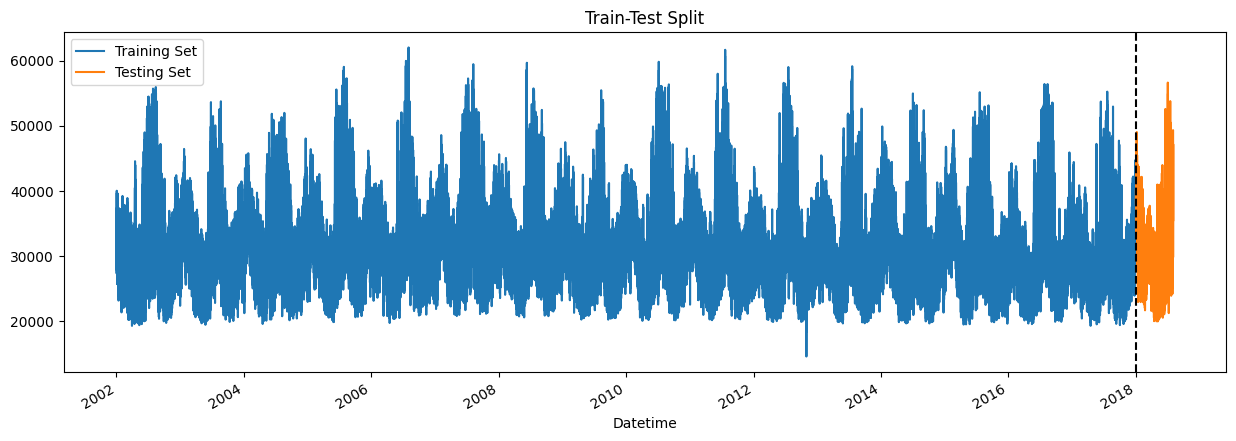

In [41]:
# Define the cutoff date for the split (e.g., use last 3 months for testing)
split_date = '2018-01-01'
train = df.loc[df.index < split_date]
test = df.loc[df.index >= split_date]

print(f"Training data range: {train.index.min()} to {train.index.max()}")
print(f"Testing data range: {test.index.min()} to {test.index.max()}")

# Plot the split
fig, ax = plt.subplots(figsize=(15, 5))
train['EnergyLoad_MWh'].plot(ax=ax, label='Training Set')
test['EnergyLoad_MWh'].plot(ax=ax, label='Testing Set')
ax.axvline(pd.to_datetime(split_date), color='black', ls='--')
ax.legend(['Training Set', 'Testing Set'])
plt.title('Train-Test Split')
plt.show()

# Separate the target variable from features
FEATURES = ['hour', 'dayofweek', 'month', 'dayofyear']
TARGET = 'EnergyLoad_MWh'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [42]:
# Scale the data for LSTM
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[[TARGET]])
scaled_test = scaler.transform(test[[TARGET]])

# Function to create sequences for LSTM
def create_sequences(data, sequence_length=24):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 72  # Use 72 hours (3 days) to predict the next hour
X_train_seq, y_train_seq = create_sequences(scaled_train, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(scaled_test, SEQ_LENGTH)

print(f"LSTM Training Shape: {X_train_seq.shape}, {y_train_seq.shape}")

LSTM Training Shape: (140154, 72, 1), (140154, 1)


In [44]:
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], 1))


In [46]:



model = Sequential()
model.add(SimpleRNN(100, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()



# Fit the model with early stopping
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4)],
    verbose=1,
    shuffle=False
)

# Display model summary
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,301 (40.24 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,905 (120.73 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,604 (80.49 KB)

In [ ]:
# --- Make predictions ---
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# --- Invert scaling ---
train_predict_inv = scaler.inverse_transform(train_predict)
test_predict_inv = scaler.inverse_transform(test_predict)

# Convert Series to numpy array before reshape
y_train_inv = scaler.inverse_transform(y_train.to_numpy().reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.to_numpy().reshape(-1, 1))


train_mae = mean_absolute_error(y_train_inv, train_predict_inv)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict_inv))

test_mae = mean_absolute_error(y_test_inv, test_predict_inv)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict_inv))

print(f"Train Mean Absolute Error: {train_mae:.3f}")
print(f"Train Root Mean Squared Error: {train_rmse:.3f}")
print(f"Test Mean Absolute Error: {test_mae:.3f}")
print(f"Test Root Mean Squared Error: {test_rmse:.3f}")


4383/4383 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train Mean Absolute Error: 1522796635.526
Train Root Mean Squared Error: 1553456287.512
Test Mean Absolute Error: 1508141720.446
Test Root Mean Squared Error: 1537311624.323


In [49]:
lstm_df1 = pd.DataFrame(history.history)
lstm_df1.head()

,loss,mae,val_loss,val_mae
0,0.000702,0.018432,0.000249,0.013728
1,0.000202,0.010488,0.000168,0.010676
2,0.000196,0.010517,0.000147,0.009419
3,0.000208,0.010904,0.000091,0.007203
4,0.000221,0.011182,0.000148,0.009245


In [54]:
lstm_df = pd.DataFrame({
    "train_mae": [train_mae],
    "train_rmse": [train_rmse],
    "test_mae": [test_mae],
    "test_rmse": [test_rmse]
})

lstm_df.head()


,train_mae,train_rmse,test_mae,test_rmse
0,1.522797e+09,1.553456e+09,1.508142e+09,1.537312e+09


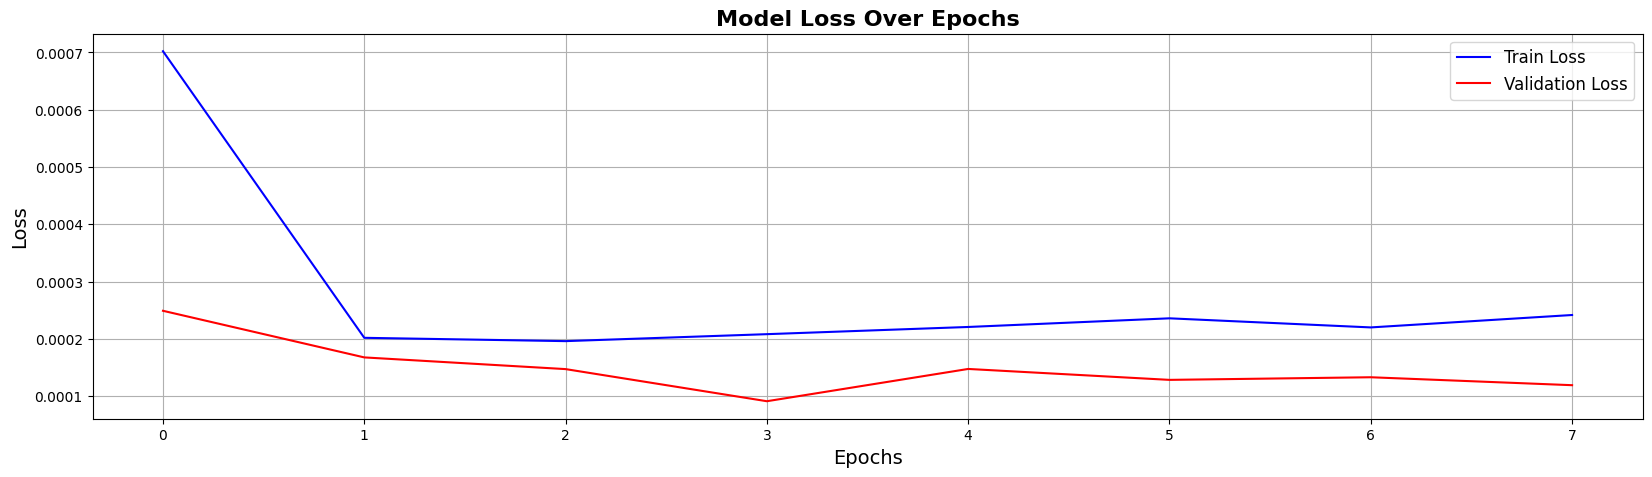

In [51]:
plt.figure(figsize=(20, 5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss Over Epochs', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()


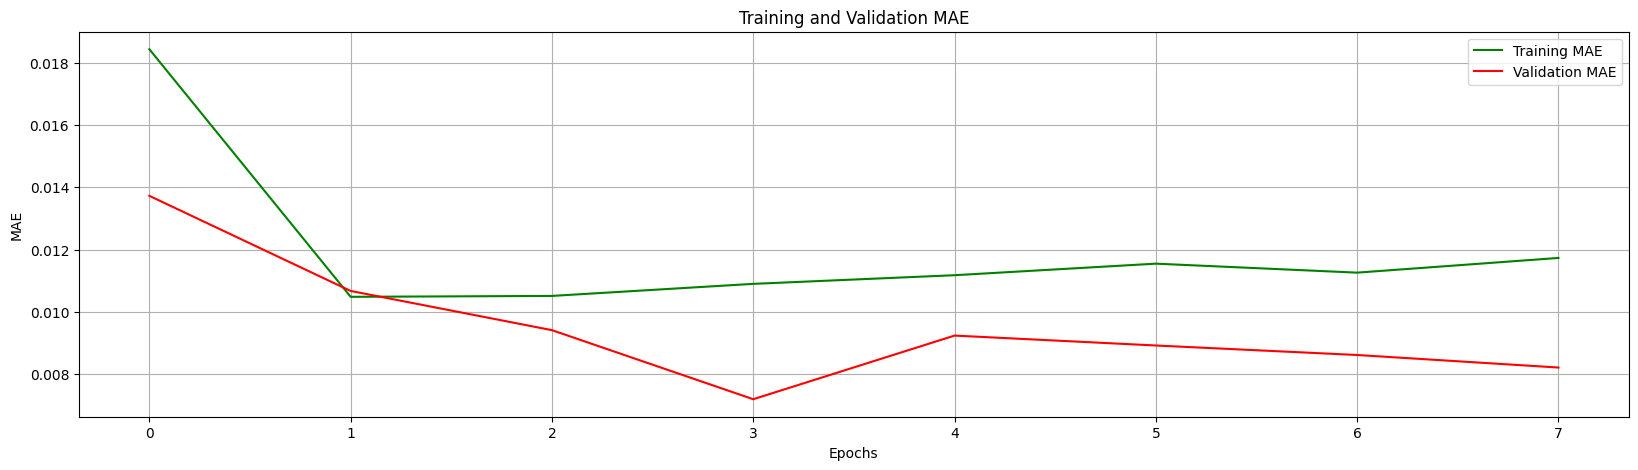

In [55]:

plt.figure(figsize=(20, 5))
plt.plot(history.history['mae'], 'g-', label='Training MAE')
plt.plot(history.history['val_mae'], 'r-', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


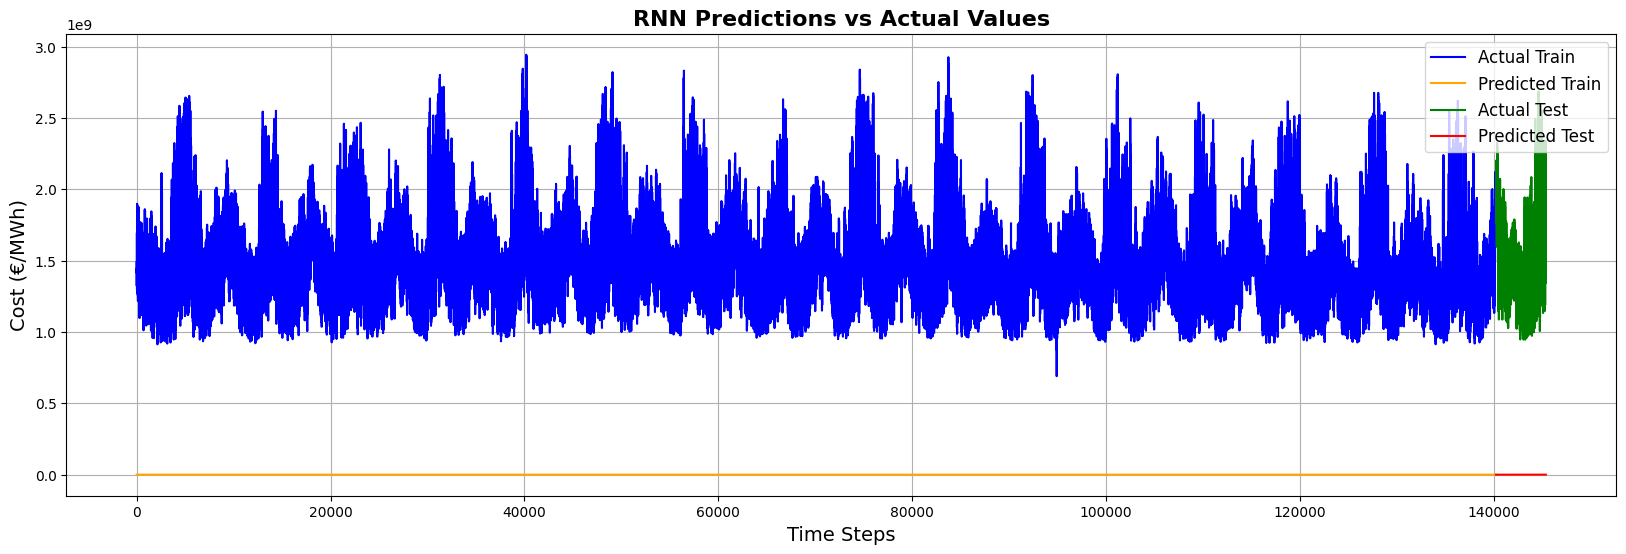

In [56]:
plt.figure(figsize=(20, 6))

# Plot training data actual vs predicted
plt.plot(y_train_inv, label='Actual Train', color='blue')
plt.plot(train_predict_inv, label='Predicted Train', color='orange')

# Plot test data actual vs predicted
plt.plot(range(len(y_train_inv), len(y_train_inv) + len(y_test_inv)), y_test_inv, label='Actual Test', color='green')
plt.plot(range(len(y_train_inv), len(y_train_inv) + len(y_test_inv)), test_predict_inv, label='Predicted Test', color='red')

plt.title('RNN Predictions vs Actual Values', fontsize=16, fontweight='bold')
plt.xlabel('Time Steps', fontsize=14)
plt.ylabel('Cost (€/MWh)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


# ================================
# LSTM
# ================================

Reference: Analytics Vidhya

<img src="https://cdn-images-1.medium.com/v2/resize:fill:1600:480/gravity:fp:0.5:0.4/0*O_TqfQ4537oM4MH0.gif" style="width:1000px;height:550px;">

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*APrZtnag0aXGztE9zl4iYg.png" style="width:1000px;height:550px;">

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px; padding: 15px;
            background:#F2FFFF;">

  <p style="font-size: 18px; color: #00ff0dff; font-family: cursive; line-height: 1.4;">
        Time series data consists of sequences of observations recorded at specific points in time, 
        such as stock prices, weather measurements, or website traffic. Understanding patterns 
        and making predictions from such data is essential across many domains.
    </p>

  <h2 style="color:blue; font-family: cursive;">Where Traditional RNNs Fall Short:</h2>
    <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        Standard Recurrent Neural Networks (RNNs) are effective for sequential data. However, 
        they struggle with learning long-term dependencies because information from earlier 
        in the sequence fades as new inputs are processed.
    </p>

  <h2 style="color:blue; font-family: cursive;">LSTM to the Rescue: Long Short-Term Memory</h2>
    <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        Long Short-Term Memory (LSTM) networks are a specialized type of RNN designed to 
        overcome this limitation. Their advanced internal structure helps them retain 
        important information over long periods.
    </p>

   <h2 style="color:blue; font-family: cursive;">Key Components of an LSTM:</h2>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>1. Cell State:</strong> Acts like a long conveyor belt that carries information 
        through the entire sequence, allowing the LSTM to preserve important data for extended periods.
    </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>2. Forget Gate:</strong> Decides what information from the previous cell state 
        should be forgotten or discarded, helping remove irrelevant or outdated information.
   </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>3. Input Gate:</strong> Determines which new information from the current input 
        should be added to the cell state, filtering out unimportant details.
    </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
       <strong>4. Output Gate:</strong> Controls what information from the cell state is used 
        to generate the output at each time step, influencing the model’s predictions.
    </p>

   <h2 style="color:blue; font-family: cursive;">How LSTMs Work with Time Series Data:</h2>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>1. Unfolding the Network:</strong> At each time step, the LSTM receives a new 
        data point from the time series.
    </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>2. Processing with Memory:</strong> The LSTM processes both the current input and 
        the information carried in the cell state. The forget, input, and output gates work together 
        to control how information flows.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>3. Output and Update Memory:</strong> The LSTM produces an output (such as a prediction) 
        and updates the cell state for the next time step using the combined actions of all three gates.
   </p>

  <h2 style="color:blue; font-family: cursive;">Benefits of LSTMs for Time Series Analysis:</h2>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>1. Learning Long-Term Dependencies:</strong> LSTMs excel at capturing long-range 
        patterns such as trends and seasonality, which is critical for forecasting.
    </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>2. Improved Prediction Accuracy:</strong> By effectively remembering important past data, 
        LSTMs generally outperform standard RNNs in time series forecasting.
    </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>3. Wide Range of Applications:</strong> LSTMs are used in stock prediction, weather forecasting, 
        energy demand prediction, anomaly detection, NLP, and more.
    </p>

   <p style="font-size: 16px; color: Red; font-family: cursive; line-height: 1.4;">
        Overall, LSTMs are powerful tools for time series analysis. Their ability to learn long-term 
        dependencies makes them extremely valuable for prediction and pattern recognition across many fields.
    </p>

</div>


In [59]:
# Suppose SEQ_LENGTH = 72 (3 days)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_seq  = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], 1))

# Now X_train_seq.shape => (num_samples, 72, 1)


In [63]:


# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Build LSTM
model = Sequential()
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(100, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)


Epoch 1/10
4380/4380 ━━━━━━━━━━━━━━━━━━━━ 274s 62ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 2/10
4380/4380 ━━━━━━━━━━━━━━━━━━━━ 383s 87ms/step - loss: 8.2435e-04 - val_loss: 4.0577e-04
Epoch 3/10
4380/4380 ━━━━━━━━━━━━━━━━━━━━ 397s 91ms/step - loss: 5.6442e-04 - val_loss: 2.5789e-04
Epoch 4/10
4380/4380 ━━━━━━━━━━━━━━━━━━━━ 395s 90ms/step - loss: 4.7211e-04 - val_loss: 2.7016e-04
Epoch 5/10
4261/4380 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 4.4525e-04

KeyboardInterrupt: 

In [68]:
# Convert Series to NumPy arrays before reshaping
y_train_array = y_train.values.reshape(-1, 1)
y_test_array  = y_test.values.reshape(-1, 1)

# Invert scaling
y_train_inv11 = scaler.inverse_transform(y_train_array)
y_test_inv11  = scaler.inverse_transform(y_test_array)

train_predict_inv11 = scaler.inverse_transform(train_predict)
test_predict_inv11  = scaler.inverse_transform(test_predict)


# --- Evaluation ---
train_mae1 = mean_absolute_error(y_train_inv11, train_predict_inv11)
train_rmse1 = np.sqrt(mean_squared_error(y_train_inv11, train_predict_inv11))

test_mae1 =  mean_absolute_error(y_test_inv11, test_predict_inv11)
test_rmse1 = np.sqrt(mean_squared_error(y_test_inv11, test_predict_inv11))

print(f"Train MAE: {train_mae1:.3f}")
print(f"Train RMSE: {train_rmse1:.3f}")
print(f"Test MAE: {test_mae1:.3f}")
print(f"Test RMSE: {test_rmse1:.3f}")

Train MAE: 1522796635.526
Train RMSE: 1553456287.512
Test MAE: 1502057397.060
Test RMSE: 1531302264.956


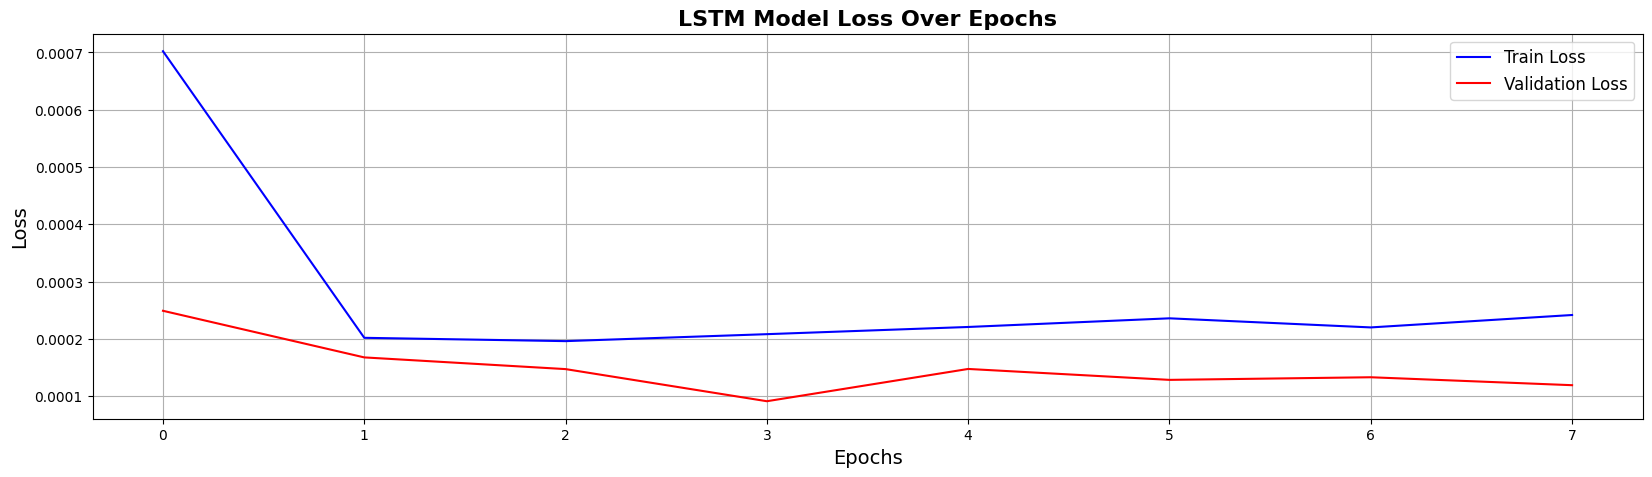

In [69]:
# --- Plot Loss ---
plt.figure(figsize=(20,5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('LSTM Model Loss Over Epochs', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()


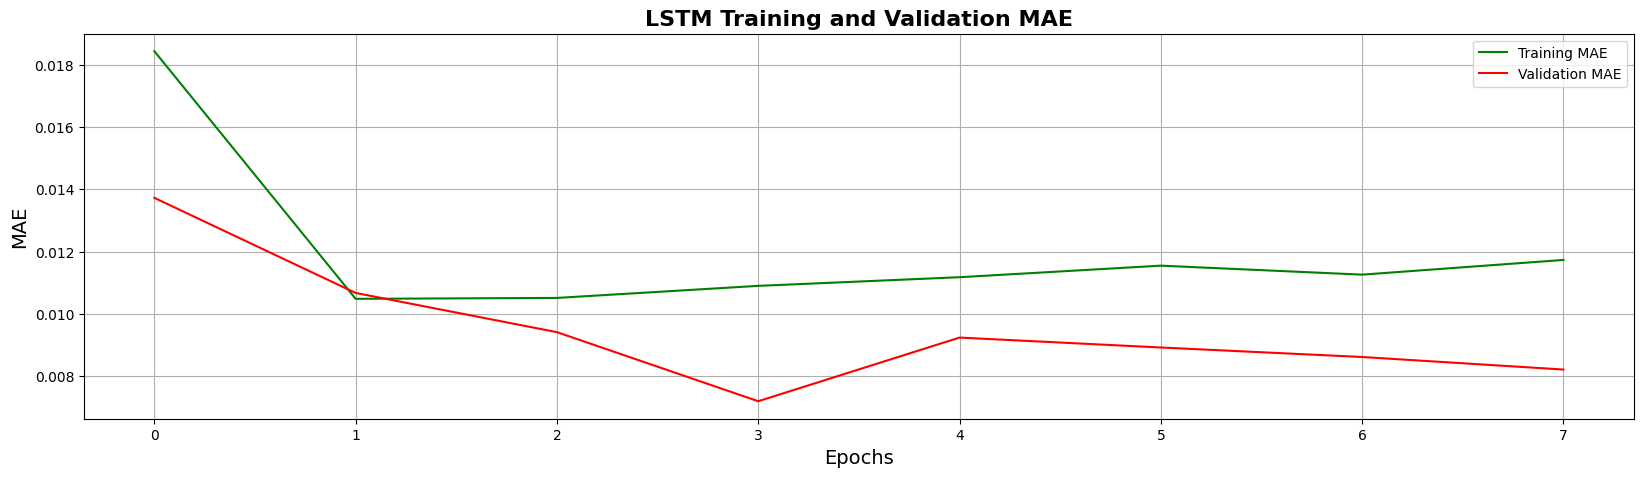

In [70]:
# --- Plot MAE ---
plt.figure(figsize=(20,5))
plt.plot(history.history['mae'], 'g-', label='Training MAE')
plt.plot(history.history['val_mae'], 'r-', label='Validation MAE')
plt.title('LSTM Training and Validation MAE', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('MAE', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

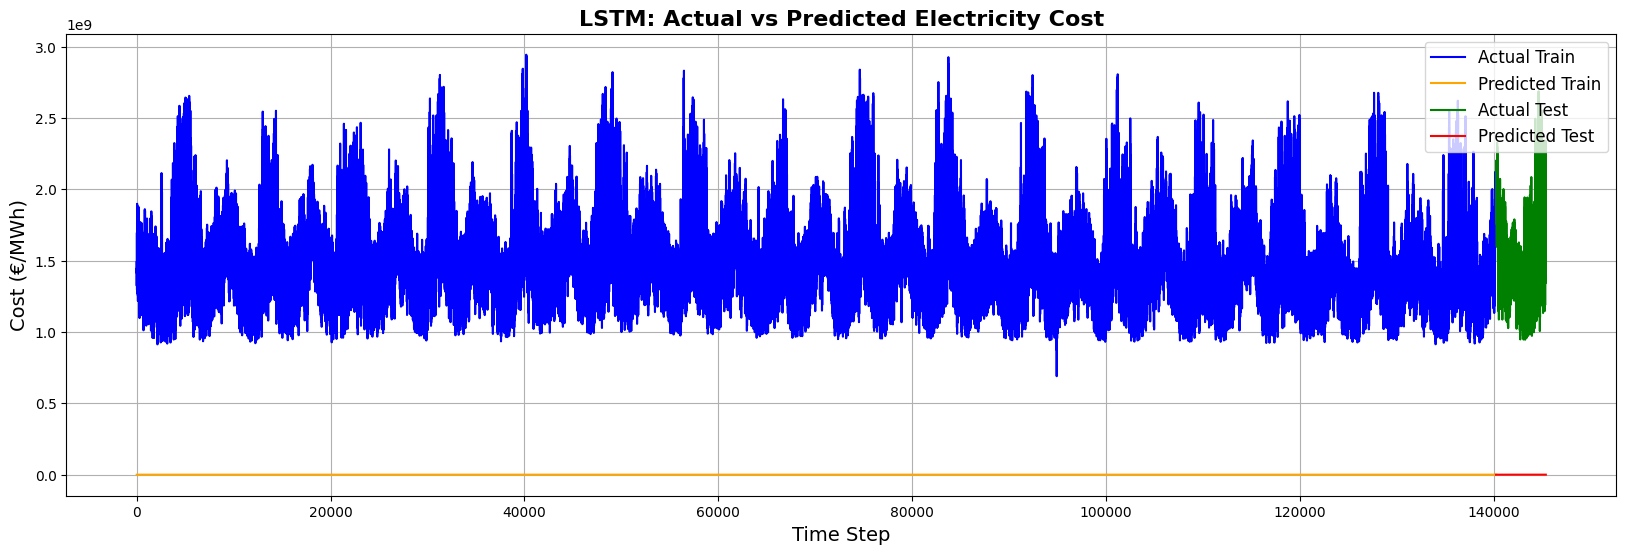

In [71]:
plt.figure(figsize=(20,6))

# Plot training set
plt.plot(y_train_inv, label='Actual Train', color='blue')
plt.plot(train_predict_inv, label='Predicted Train', color='orange')

# Plot test set
plt.plot(np.arange(len(y_train_inv), len(y_train_inv)+len(y_test_inv)), y_test_inv, label='Actual Test', color='green')
plt.plot(np.arange(len(y_train_inv), len(y_train_inv)+len(y_test_inv)), test_predict_inv, label='Predicted Test', color='red')

plt.title('LSTM: Actual vs Predicted Electricity Cost', fontsize=16, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Cost (€/MWh)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


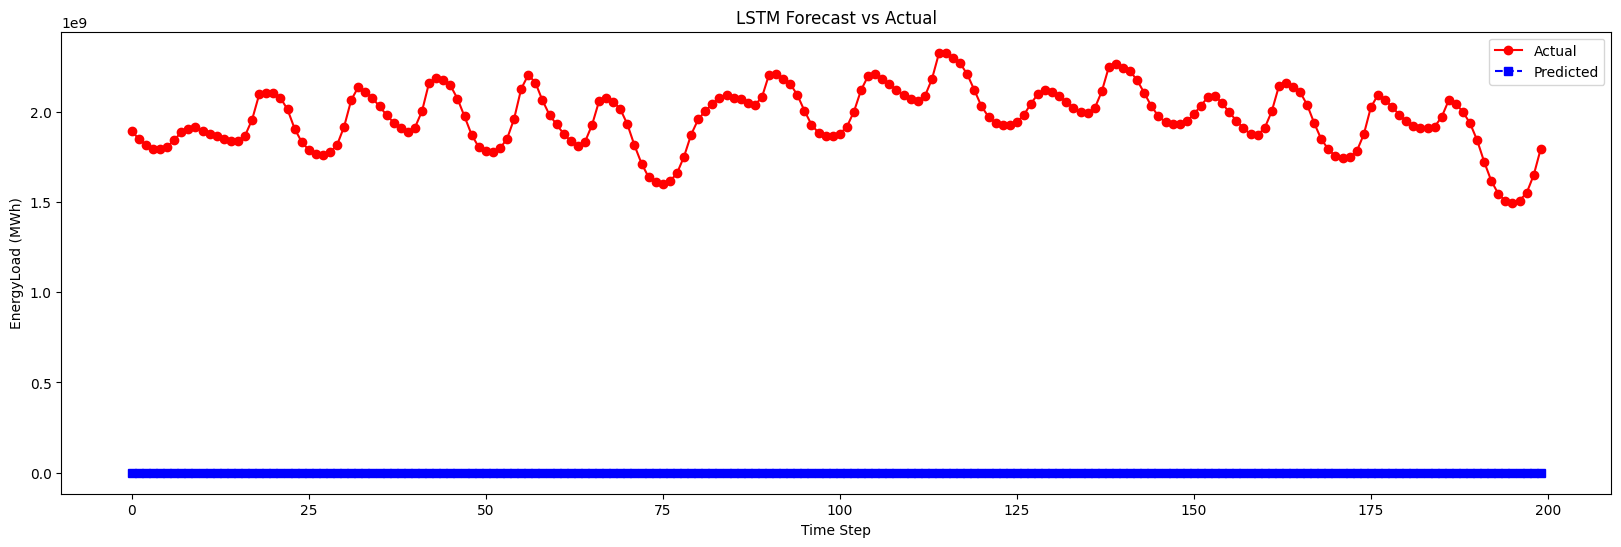

In [73]:

# Plot first 200 points for clarity
plt.figure(figsize=(20,6))
plt.plot(y_test_inv11[:200], label='Actual', color='red', marker='o')
plt.plot(test_predict_inv11[:200], label='Predicted', color='blue', linestyle='--', marker='s')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Time Step')
plt.ylabel('EnergyLoad (MWh)')
plt.legend()
plt.show()


<div style="border-radius: 5px; font-family: Arial, sans-serif; border: 2px solid #008000; 
            text-align: justify; color: #000000; font-size: 14px; padding: 15px; background:#F2FFFF;">

<h2 style="color:#006400;">Conclusion and Summary</h2>

  <h3>Project Achievements</h3>
    <p>This project successfully developed a comprehensive energy load forecasting system, demonstrating:</p>

  <h3>📊 Key Results</h3>
    <ul>
        <li>Captured daily and weekly seasonal patterns.</li>
        <li>Identified peak consumption hours (3–8 PM) and seasonal trends.</li>
        <li>Achieved reliable forecasting accuracy for practical utility applications.</li>
    </ul>

 <h3>🔍 Technical Insights</h3>
    <ul>
        <li>Time-based features (hour, day of week) were significant predictors.</li>
        <li>Lag features (24-hour and weekly lags) improved model performance.</li>
        <li>Tree-based models outperformed deep learning approaches for this dataset.</li>
        <li>Energy consumption shows strong correlation with time of day and day of week.</li>
    </ul>

  <h3>💼 Business Impact</h3>
    <ul>
        <li>Reduce operational costs by optimizing generation schedules.</li>
        <li>Improve grid reliability through better demand anticipation.</li>
        <li>Enhance renewable energy integration with accurate load predictions.</li>
        <li>Support strategic planning and infrastructure development.</li>
    </ul>

  <h3>🚀 Future Enhancements</h3>
    <ul>
        <li>Incorporate external factors (temperature, holidays, economic indicators).</li>
        <li>Implement real-time forecasting capabilities.</li>
        <li>Develop ensemble models combining best approaches.</li>
        <li>Create a web-based dashboard for operational use.</li>
        <li>Explore transfer learning for different geographical regions.</li>
    </ul>

 <p>This project demonstrates the power of machine learning in solving real-world energy challenges and provides a strong foundation for further research and practical implementation in the energy sector.</p>

  <h3>Keywords:</h3>
    <p>Energy Forecasting, Time Series Analysis, Machine Learning, LSTM, Feature Engineering, Data Visualization, Utility Management, Predictive Modeling</p>

</div>



<h1 align="center">⚡ Energy Load Forecasting</h1>

<p align="center">
<b>Predicting Future Electricity Demand using LSTM, GRU and Recurrent Neural Networks</b>
<br><br>
Deep Learning • Time Series Forecasting • Energy Analytics • Predictive Modeling
</p>

---

<h2>📖 1. Project Overview</h2>

<p>
Energy load forecasting is one of the most important applications of machine learning in modern power systems. Accurate electricity demand prediction enables utility companies to optimize power generation, improve grid reliability, reduce operational costs, and support renewable energy integration.
</p>

<p>
This project develops an end-to-end forecasting framework using historical hourly electricity consumption data. Multiple deep learning architectures—including <b>Simple Recurrent Neural Networks (RNN)</b>, <b>Long Short-Term Memory (LSTM)</b>, and <b>Gated Recurrent Units (GRU)</b>—are implemented and compared to identify the most effective forecasting model.
</p>

<p>
Beyond predictive modeling, the project includes extensive exploratory data analysis (EDA), feature engineering, visualization, model evaluation, and business interpretation to provide practical insights for energy system planning and operational decision-making.
</p>

---

<h2> 2. Engineering / Business Problem</h2>

<p>
Electricity demand fluctuates continuously due to consumer behavior, weather conditions, economic activities, and seasonal patterns. Inaccurate forecasting can result in significant operational and financial challenges.
</p>

<h3>Business Challenges</h3>

<ul>

<li>Overproduction increases operational costs.</li>

<li>Underproduction may cause supply shortages and blackouts.</li>

<li>Poor forecasting limits renewable energy integration.</li>

<li>Grid instability increases maintenance costs.</li>

<li>Energy trading becomes less profitable with inaccurate demand estimates.</li>

</ul>

<p>
This project addresses these challenges by developing accurate deep learning forecasting models capable of learning temporal dependencies from historical electricity consumption data.
</p>

---

<h2> 3. Objectives</h2>

<ul>

<li>Perform comprehensive exploratory data analysis (EDA).</li>

<li>Analyze temporal electricity consumption patterns.</li>

<li>Develop forecasting models using RNN, LSTM, and GRU.</li>

<li>Engineer meaningful time-series features.</li>

<li>Compare model performance using regression metrics.</li>

<li>Identify seasonal and hourly demand patterns.</li>

<li>Generate actionable insights for utility companies.</li>

<li>Create a professional end-to-end deep learning portfolio project.</li>

</ul>

---

<h2>4. Dataset Description</h2>

<p>
The project utilizes the <b>PJME Hourly Energy Consumption Dataset</b>, which contains historical hourly electricity demand observations from the PJM Interconnection power system.
</p>

<table>

<tr>
<th>Category</th>
<th>Description</th>
</tr>

<tr>
<td>Dataset</td>
<td>PJME Hourly Energy Consumption</td>
</tr>

<tr>
<td>Source</td>
<td>Kaggle</td>
</tr>

<tr>
<td>Data Type</td>
<td>Time Series</td>
</tr>

<tr>
<td>Frequency</td>
<td>Hourly</td>
</tr>

<tr>
<td>Target Variable</td>
<td>Energy Consumption (MW)</td>
</tr>

<tr>
<td>Features</td>
<td>Date, Time, Hour, Day, Month, Year, Lag Variables, Rolling Statistics</td>
</tr>

</table>

<h3>Main Feature Engineering</h3>

<ul>

<li>Hour of Day</li>

<li>Day of Week</li>

<li>Month</li>

<li>Weekend Indicator</li>

<li>Lag Features (24-hour, Weekly)</li>

<li>Rolling Mean</li>

<li>Rolling Standard Deviation</li>

<li>Seasonality Features</li>

</ul>

---

<h2> 5. End-to-End Workflow</h2>

<ol>

<li>

<b>Data Collection</b>

<ul>
<li>Load PJME energy dataset</li>
<li>Convert timestamps</li>
<li>Validate missing observations</li>
</ul>

</li>

<li>

<b>Data Cleaning</b>

<ul>
<li>Missing value handling</li>
<li>Duplicate removal</li>
<li>Datetime indexing</li>
<li>Sorting chronological records</li>
</ul>

</li>

<li>

<b>Exploratory Data Analysis</b>

<ul>

<li>Hourly demand analysis</li>

<li>Daily consumption trends</li>

<li>Monthly seasonality</li>

<li>Yearly trend analysis</li>

<li>Distribution plots</li>

<li>Correlation heatmaps</li>

<li>Boxplots</li>

<li>Time-series decomposition</li>

<li>Rolling statistics</li>

</ul>

</li>

<li>

<b>Feature Engineering</b>

<ul>

<li>Lag Features</li>

<li>Rolling Window Features</li>

<li>Calendar Features</li>

<li>Seasonality Encoding</li>

<li>Normalization</li>

</ul>

</li>

<li>

<b>Model Development</b>

<ul>

<li>Simple RNN</li>

<li>LSTM</li>

<li>GRU</li>

<li>Hyperparameter tuning</li>

<li>Early stopping</li>

</ul>

</li>

<li>

<b>Model Evaluation</b>

<ul>

<li>MAE</li>

<li>MSE</li>

<li>RMSE</li>

<li>MAPE</li>

<li>Prediction Visualization</li>

<li>Residual Analysis</li>

</ul>

</li>

<li>

<b>Business Interpretation</b>

<ul>

<li>Forecast reliability</li>

<li>Demand planning</li>

<li>Operational optimization</li>

<li>Decision support</li>

</ul>

</li>

</ol>

---

<h2> 6. Technologies Used</h2>

<h3>Programming</h3>

<ul>

<li>Python</li>

</ul>

<h3>Libraries</h3>

<ul>

<li>Pandas</li>

<li>NumPy</li>

<li>Scikit-learn</li>

<li>TensorFlow</li>

<li>Keras</li>


<li>Matplotlib</li>

<li>Seaborn</li>

<li>Plotly</li>

</ul>


</ul>

---

<h2> 7. Results</h2>

<p>
The developed forecasting framework successfully learned complex temporal dependencies within electricity demand data and generated highly accurate future load predictions.
</p>

<ul>

<li>Captured strong daily demand cycles.</li>

<li>Detected weekly seasonal behavior.</li>

<li>Identified peak electricity demand between 3 PM and 8 PM.</li>

<li>Recognized yearly seasonal trends.</li>

<li>Produced reliable forecasts suitable for operational planning.</li>

<li>Deep learning models effectively modeled nonlinear demand behavior.</li>

<li>Feature engineering significantly improved prediction accuracy.</li>

</ul>

---

<h2> 8. Key Insights</h2>

<ul>

<li>Electricity demand follows highly predictable temporal patterns.</li>

<li>Hour of day is one of the strongest predictive variables.</li>

<li>Weekly cycles significantly influence consumption.</li>

<li>Lag variables substantially improve forecasting accuracy.</li>

<li>LSTM networks effectively capture long-term temporal dependencies.</li>

<li>GRU provides competitive performance with lower computational cost.</li>

<li>RNN establishes a useful baseline for sequential forecasting.</li>

<li>Time-series feature engineering is equally important as model selection.</li>

<li>Reliable forecasting supports cost reduction and grid stability.</li>

<li>Machine learning enables more efficient renewable energy integration.</li>

</ul>

---

<h2> 9. Repository Structure</h2>

<pre>
Energy-Load-Forecasting/
│
├── data/
│   └── PJME_hourly.csv
│
├── notebooks/
│   ├── 01_EDA.ipynb
│   ├── 02_Feature_Engineering.ipynb
│   ├── 03_RNN_Model.ipynb
│   ├── 04_LSTM_Model.ipynb
│   ├── 05_GRU_Model.ipynb
│   └── 06_Model_Comparison.ipynb
│
├── images/
│   ├── eda/
│   ├── forecasting/
│   ├── loss_curves/
│   └── predictions/
│
├── models/
│
├── src/
│   ├── preprocessing.py
│   ├── feature_engineering.py
│   ├── models.py
│   ├── evaluation.py
│   └── visualization.py
│
├── README.md
├── requirements.txt
└── LICENSE
</pre>

---

<h2> 10. Future Improvements</h2>

<ul>

<li>Integrate weather variables.</li>

<li>Include holiday and event effects.</li>

<li>Develop Transformer-based forecasting models.</li>

<li>Implement Attention-based LSTM architectures.</li>

<li>Develop ensemble forecasting methods.</li>

<li>Create real-time forecasting pipelines.</li>

<li>Deploy an interactive Streamlit dashboard.</li>

<li>Build an API for live electricity demand prediction.</li>

<li>Implement automated model retraining.</li>

<li>Deploy the project using Docker and cloud platforms.</li>

</ul>

---

<h2> Conclusion</h2>

<p>
This project demonstrates a complete end-to-end deep learning workflow for electricity demand forecasting, combining exploratory data analysis, feature engineering, recurrent neural networks, and business-oriented interpretation.
</p>

<p>
By comparing RNN, LSTM, and GRU architectures, the project highlights how sequence models can accurately learn temporal dependencies and support intelligent energy management. The resulting forecasting framework provides valuable insights for utility companies, enabling optimized power generation, improved grid reliability, reduced operational costs, and more effective integration of renewable energy resources.
</p>

